# 03 – Statistical Analysis & Modeling
## CIP_FS26_203 | Weather & Electricity Prices in Switzerland

**Overall Hypothesis**
Weather variables (temperature, solar radiation, wind speed, and cloud cover) significantly influence electricity load and day-ahead electricity prices in Switzerland, as evidenced by non-zero correlations, significant regression coefficients, and improved out-of-sample predictive performance compared to a baseline model.

This notebook performs the statistical analysis to answer the research questions with the goal of either rejecting or supporting this hypothesis:

- **RQ1** – Correlation between temperature and day-ahead electricity prices
- **RQ2** – Impact of temperature and solar radiation on electricity load
- **RQ3** – Predictive modeling of electricity prices using meteorological variables

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from scipy.stats import shapiro
import scipy.stats as stats
import statsmodels
import os

# --- Display settings ---
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.2f}".format)
sns.set_theme(style="whitegrid")

print("Analysis environment ready!")

Analysis environment ready!


## 1. Data Integration
In this step, we load the cleaned datasets for weather, prices, and load, and merge them into a single master dataframe for analysis.

In [52]:
# --- Define file paths ---
path_prices = "../data/processed/entsoe_prices_clean.csv"
path_weather = "../data/processed/weather_clean.csv"
path_load_daily = "../data/processed/swissgrid_load_clean_daily.csv"

# --- Load processed data ---
df_prices = pd.read_csv(path_prices, parse_dates=["date"])
df_weather = pd.read_csv(path_weather, parse_dates=["date"])
df_load_daily = pd.read_csv(path_load_daily, parse_dates=["date"])

print("Files loaded successfully!")
print(f"Prices shape: {df_prices.shape}")
print(f"Weather shape: {df_weather.shape}")
print(f"Daily load shape: {df_load_daily.shape}")

Files loaded successfully!
Prices shape: (4017, 2)
Weather shape: (16072, 14)
Daily load shape: (4018, 6)


In [53]:
# --- Inspect weather structure ---
print("Unique cities in weather data:")
print(df_weather["city"].unique())

print("\nWeather rows per date (should be 4 if one row per city):")
display(df_weather.groupby("date").size().value_counts().sort_index())

print("\nWeather columns:")
print(df_weather.columns.tolist())

Unique cities in weather data:
<StringArray>
['Zurich', 'Basel', 'Geneva', 'Lugano']
Length: 4, dtype: str

Weather rows per date (should be 4 if one row per city):


4    4018
Name: count, dtype: int64


Weather columns:
['temperature_2m_mean', 'temperature_2m_max', 'temperature_2m_min', 'precipitation_sum', 'windspeed_10m_max', 'shortwave_radiation_sum', 'cloudcover_mean', 'sunshine_duration', 'date', 'city', 'season', 'apparent_temperature_mean', 'apparent_temperature_max', 'apparent_temperature_min']


In [54]:
# --- Aggregate city-level weather to one daily Swiss proxy ---
weather_numeric_cols = [
    "temperature_2m_mean",
    "temperature_2m_max",
    "temperature_2m_min",
    "precipitation_sum",
    "windspeed_10m_max",
    "shortwave_radiation_sum",
    "cloudcover_mean",
    "sunshine_duration",
    "apparent_temperature_mean",
    "apparent_temperature_max",
    "apparent_temperature_min"
]

df_weather_daily = (
    df_weather
    .groupby("date")[weather_numeric_cols]
    .mean()
    .reset_index()
)

print(f"Aggregated daily weather shape: {df_weather_daily.shape}")
display(df_weather_daily.head())

Aggregated daily weather shape: (4018, 12)


,date,temperature_2m_mean,temperature_2m_max,temperature_2m_min,precipitation_sum,windspeed_10m_max,shortwave_radiation_sum,cloudcover_mean,sunshine_duration,apparent_temperature_mean,apparent_temperature_max,apparent_temperature_min
0,2015-01-01,4.00,7.10,0.10,0.00,6.30,6.18,7.00,30686.13,-3.35,0.90,-7.28
1,2015-01-02,6.40,11.90,0.80,0.00,10.50,5.95,71.00,25552.94,-1.45,3.92,-7.15
2,2015-01-03,9.40,12.70,7.50,0.00,12.30,5.50,56.00,28179.38,2.55,5.92,0.20
3,2015-01-04,7.60,12.10,2.70,0.00,13.00,6.24,13.00,30869.75,1.92,5.62,-2.50
4,2015-01-05,6.70,10.30,2.20,0.00,12.20,6.63,6.00,30941.12,-0.82,4.28,-4.85


In [55]:
# --- Create daily master dataset for RQ1 and RQ3 ---
df_daily = (
    df_prices
    .merge(df_weather_daily, on="date", how="inner")
    .merge(df_load_daily, on="date", how="inner")
    .sort_values("date")
    .reset_index(drop=True)
)

print(f"Daily master created: {df_daily.shape}")
display(df_daily.head())

Daily master created: (4017, 18)


,date,price_eur_mwh,temperature_2m_mean,temperature_2m_max,temperature_2m_min,precipitation_sum,windspeed_10m_max,shortwave_radiation_sum,cloudcover_mean,sunshine_duration,apparent_temperature_mean,apparent_temperature_max,apparent_temperature_min,load_end_users_ch_mw,load_ti_mw,load_bl_bs_mw,load_sh_zh_mw,load_ge_vd_mw
0,2015-01-01,36.63,4.00,7.10,0.10,0.00,6.30,6.18,7.00,30686.13,-3.35,0.90,-7.28,6494.98,349.75,368.41,1040.95,902.98
1,2015-01-02,41.61,6.40,11.90,0.80,0.00,10.50,5.95,71.00,25552.94,-1.45,3.92,-7.15,6669.69,367.37,404.23,1073.88,841.13
2,2015-01-03,36.59,9.40,12.70,7.50,0.00,12.30,5.50,56.00,28179.38,2.55,5.92,0.20,6563.43,361.62,394.23,1076.14,902.75
3,2015-01-04,31.72,7.60,12.10,2.70,0.00,13.00,6.24,13.00,30869.75,1.92,5.62,-2.50,6164.34,334.32,366.04,1023.15,936.20
4,2015-01-05,47.39,6.70,10.30,2.20,0.00,12.20,6.63,6.00,30941.12,-0.82,4.28,-4.85,7688.85,351.02,456.71,1278.68,993.77


In [56]:
# --- Validate daily master dataset ---
print("Daily master info:")
print(df_daily.info())

print("\nMissing values per column:")
print(df_daily.isnull().sum())

print("\nDate range:")
print("Min date:", df_daily["date"].min())
print("Max date:", df_daily["date"].max())

print("\nDuplicate dates:", df_daily["date"].duplicated().sum())

Daily master info:
<class 'pandas.DataFrame'>
RangeIndex: 4017 entries, 0 to 4016
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   date                       4017 non-null   datetime64[us]
 1   price_eur_mwh              4017 non-null   float64       
 2   temperature_2m_mean        4017 non-null   float64       
 3   temperature_2m_max         4017 non-null   float64       
 4   temperature_2m_min         4017 non-null   float64       
 5   precipitation_sum          4017 non-null   float64       
 6   windspeed_10m_max          4017 non-null   float64       
 7   shortwave_radiation_sum    4017 non-null   float64       
 8   cloudcover_mean            4017 non-null   float64       
 9   sunshine_duration          4017 non-null   float64       
 10  apparent_temperature_mean  4017 non-null   float64       
 11  apparent_temperature_max   4017 non-null   float64       
 12

In [57]:
# --- Create weekly master dataset for RQ2 ---
df_weekly = (
    df_daily
    .set_index("date")
    .resample("W")
    .mean(numeric_only=True)
    .reset_index()
)

print(f"Weekly master created: {df_weekly.shape}")
display(df_weekly.head())

Weekly master created: (575, 18)


,date,price_eur_mwh,temperature_2m_mean,temperature_2m_max,temperature_2m_min,precipitation_sum,windspeed_10m_max,shortwave_radiation_sum,cloudcover_mean,sunshine_duration,apparent_temperature_mean,apparent_temperature_max,apparent_temperature_min,load_end_users_ch_mw,load_ti_mw,load_bl_bs_mw,load_sh_zh_mw,load_ge_vd_mw
0,2015-01-04,36.64,6.85,10.95,2.78,0.00,10.53,5.97,36.75,28822.05,-0.08,4.09,-4.18,6473.11,353.26,383.23,1053.53,895.77
1,2015-01-11,43.11,7.83,11.21,3.97,0.01,10.50,6.22,33.43,30693.50,2.02,5.93,-1.54,7353.99,362.60,438.98,1206.66,946.09
2,2015-01-18,42.86,5.99,7.76,3.67,13.27,7.24,3.29,67.57,14054.14,1.14,4.93,-2.10,7498.33,396.18,443.58,1216.96,937.46
3,2015-01-25,47.58,2.49,5.57,-0.63,4.03,9.86,5.48,59.00,20580.19,-1.97,0.65,-4.59,7793.87,403.31,456.67,1257.50,961.73
4,2015-02-01,45.91,3.17,5.43,0.36,0.94,8.81,7.86,61.14,31216.22,-2.44,-0.39,-4.76,7818.88,408.53,455.45,1253.72,979.57


In [58]:
# --- Feature engineering for daily data ---
df_daily["year"] = df_daily["date"].dt.year
df_daily["month"] = df_daily["date"].dt.month
df_daily["weekday"] = df_daily["date"].dt.weekday
df_daily["is_weekend"] = df_daily["weekday"] >= 5

print("Daily feature engineering completed.")
display(df_daily.head())

Daily feature engineering completed.


,date,price_eur_mwh,temperature_2m_mean,temperature_2m_max,temperature_2m_min,precipitation_sum,windspeed_10m_max,shortwave_radiation_sum,cloudcover_mean,sunshine_duration,apparent_temperature_mean,apparent_temperature_max,apparent_temperature_min,load_end_users_ch_mw,load_ti_mw,load_bl_bs_mw,load_sh_zh_mw,load_ge_vd_mw,year,month,weekday,is_weekend
0,2015-01-01,36.63,4.00,7.10,0.10,0.00,6.30,6.18,7.00,30686.13,-3.35,0.90,-7.28,6494.98,349.75,368.41,1040.95,902.98,2015,1,3,False
1,2015-01-02,41.61,6.40,11.90,0.80,0.00,10.50,5.95,71.00,25552.94,-1.45,3.92,-7.15,6669.69,367.37,404.23,1073.88,841.13,2015,1,4,False
2,2015-01-03,36.59,9.40,12.70,7.50,0.00,12.30,5.50,56.00,28179.38,2.55,5.92,0.20,6563.43,361.62,394.23,1076.14,902.75,2015,1,5,True
3,2015-01-04,31.72,7.60,12.10,2.70,0.00,13.00,6.24,13.00,30869.75,1.92,5.62,-2.50,6164.34,334.32,366.04,1023.15,936.20,2015,1,6,True
4,2015-01-05,47.39,6.70,10.30,2.20,0.00,12.20,6.63,6.00,30941.12,-0.82,4.28,-4.85,7688.85,351.02,456.71,1278.68,993.77,2015,1,0,False


In [59]:
# --- Feature engineering for weekly data ---
df_weekly["year"] = df_weekly["date"].dt.year
df_weekly["month"] = df_weekly["date"].dt.month

print("Weekly feature engineering completed.")
display(df_weekly.head())

Weekly feature engineering completed.


,date,price_eur_mwh,temperature_2m_mean,temperature_2m_max,temperature_2m_min,precipitation_sum,windspeed_10m_max,shortwave_radiation_sum,cloudcover_mean,sunshine_duration,apparent_temperature_mean,apparent_temperature_max,apparent_temperature_min,load_end_users_ch_mw,load_ti_mw,load_bl_bs_mw,load_sh_zh_mw,load_ge_vd_mw,year,month
0,2015-01-04,36.64,6.85,10.95,2.78,0.00,10.53,5.97,36.75,28822.05,-0.08,4.09,-4.18,6473.11,353.26,383.23,1053.53,895.77,2015,1
1,2015-01-11,43.11,7.83,11.21,3.97,0.01,10.50,6.22,33.43,30693.50,2.02,5.93,-1.54,7353.99,362.60,438.98,1206.66,946.09,2015,1
2,2015-01-18,42.86,5.99,7.76,3.67,13.27,7.24,3.29,67.57,14054.14,1.14,4.93,-2.10,7498.33,396.18,443.58,1216.96,937.46,2015,1
3,2015-01-25,47.58,2.49,5.57,-0.63,4.03,9.86,5.48,59.00,20580.19,-1.97,0.65,-4.59,7793.87,403.31,456.67,1257.50,961.73,2015,1
4,2015-02-01,45.91,3.17,5.43,0.36,0.94,8.81,7.86,61.14,31216.22,-2.44,-0.39,-4.76,7818.88,408.53,455.45,1253.72,979.57,2015,2


In [60]:
print("Integration summary:")
print(f"- Daily master rows: {len(df_daily)}")
print(f"- Weekly master rows: {len(df_weekly)}")
print(f"- Daily date range: {df_daily['date'].min().date()} to {df_daily['date'].max().date()}")
print(f"- Weekly date range: {df_weekly['date'].min().date()} to {df_weekly['date'].max().date()}")
print(f"- Daily duplicate dates: {df_daily['date'].duplicated().sum()}")
print(f"- Weekly duplicate dates: {df_weekly['date'].duplicated().sum()}")

Integration summary:
- Daily master rows: 4017
- Weekly master rows: 575
- Daily date range: 2015-01-01 to 2025-12-30
- Weekly date range: 2015-01-04 to 2026-01-04
- Daily duplicate dates: 0
- Weekly duplicate dates: 0


The datasets were successfully merged into a consistent daily and weekly master dataset without missing dates or duplicates, covering the full period from 2015 to 2025 and providing a solid basis for subsequent statistical analysis.

## 2. Research Question 1: Temperature and Electricity Prices
**RQ1:** To what extent does daily mean temperature correlate with day-ahead electricity spot prices in Switzerland over 2015–2025?

- **H0₁:** There is no linear correlation between daily mean temperature (actual and apparent) and day-ahead electricity spot prices in Switzerland (r = 0).
- **H1₁:** There is a significant linear correlation between daily mean temperature (actual and apparent) and day-ahead electricity spot prices in Switzerland (r ≠ 0).

The analysis considers both actual daily mean temperature and apparent (felt) daily mean temperature. Pearson’s correlation coefficient (*r*) and the corresponding *p*-value are used to assess the strength and statistical significance of the linear relationship.

In [61]:
# --- Prepare data for RQ1 ---
rq1_data = df_daily[[
    "date",
    "price_eur_mwh",
    "temperature_2m_mean",
    "apparent_temperature_mean"
]].dropna().copy()

print(f"RQ1 dataset shape: {rq1_data.shape}")
display(rq1_data.head())

RQ1 dataset shape: (4017, 4)


,date,price_eur_mwh,temperature_2m_mean,apparent_temperature_mean
0,2015-01-01,36.63,4.00,-3.35
1,2015-01-02,41.61,6.40,-1.45
2,2015-01-03,36.59,9.40,2.55
3,2015-01-04,31.72,7.60,1.92
4,2015-01-05,47.39,6.70,-0.82


In [62]:
# --- Pearson correlation: actual temperature vs electricity price ---
corr_temp, p_temp = pearsonr(
    rq1_data["temperature_2m_mean"],
    rq1_data["price_eur_mwh"]
)

print("RQ1 – Actual Temperature")
print(f"Pearson correlation coefficient (r): {corr_temp:.4f}")
print(f"P-value: {p_temp:.4e}")

RQ1 – Actual Temperature
Pearson correlation coefficient (r): -0.0455
P-value: 3.8883e-03


In [63]:
# --- Pearson correlation: apparent temperature vs electricity price ---
corr_app, p_app = pearsonr(
    rq1_data["apparent_temperature_mean"],
    rq1_data["price_eur_mwh"]
)

print("RQ1 – Apparent Temperature")
print(f"Pearson correlation coefficient (r): {corr_app:.4f}")
print(f"P-value: {p_app:.4e}")

RQ1 – Apparent Temperature
Pearson correlation coefficient (r): -0.0579
P-value: 2.4070e-04


In [64]:
# --- Compare actual vs apparent temperature correlation results ---
rq1_results = pd.DataFrame({
    "temperature_variable": ["temperature_2m_mean", "apparent_temperature_mean"],
    "pearson_r": [corr_temp, corr_app],
    "p_value": [p_temp, p_app]
})

display(rq1_results)

,temperature_variable,pearson_r,p_value
0,temperature_2m_mean,-0.05,0.00
1,apparent_temperature_mean,-0.06,0.00


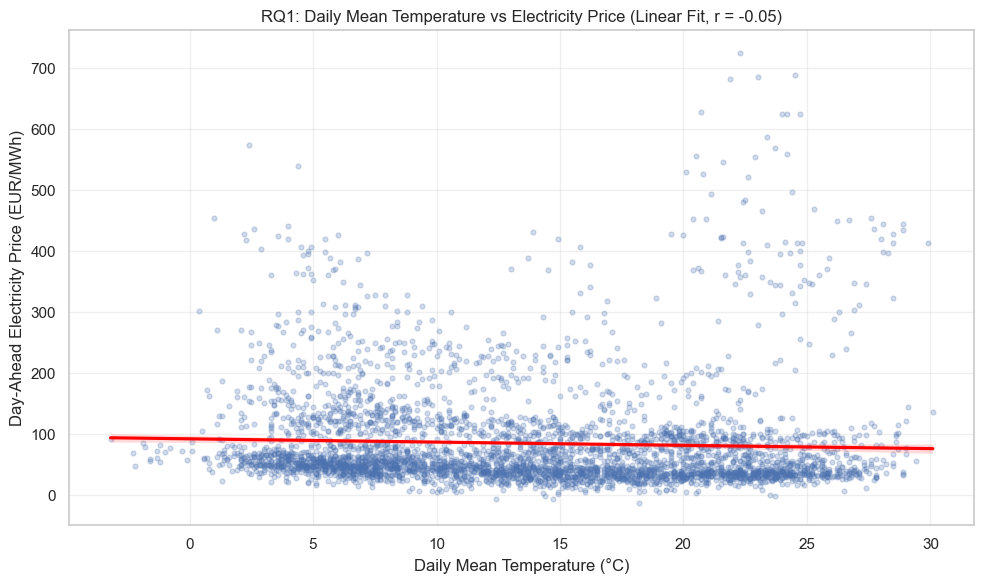

In [65]:
# --- Visualization: actual temperature vs electricity price ---
plt.figure(figsize=(10, 6))
sns.regplot(
    data=rq1_data,
    x="temperature_2m_mean",
    y="price_eur_mwh",
    scatter_kws={"alpha": 0.25, "s": 12},
    line_kws={"color": "red"}
)

plt.title(f"RQ1: Daily Mean Temperature vs Electricity Price (Linear Fit, r = {corr_temp:.2f})")
plt.xlabel("Daily Mean Temperature (°C)")
plt.ylabel("Day-Ahead Electricity Price (EUR/MWh)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

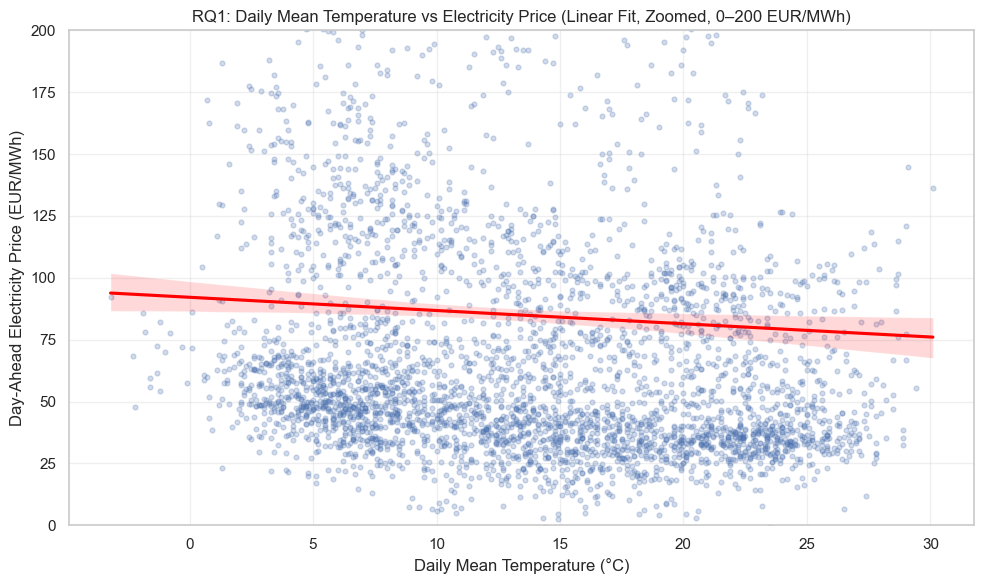

In [66]:
# --- Zoomed visualization: actual temperature vs electricity price (0-200 EUR/MWh) ---
plt.figure(figsize=(10, 6))
sns.regplot(
    data=rq1_data,
    x="temperature_2m_mean",
    y="price_eur_mwh",
    scatter_kws={"alpha": 0.25, "s": 12},
    line_kws={"color": "red"}
)

plt.ylim(0, 200)
plt.title(f"RQ1: Daily Mean Temperature vs Electricity Price (Linear Fit, Zoomed, 0–200 EUR/MWh)")
plt.xlabel("Daily Mean Temperature (°C)")
plt.ylabel("Day-Ahead Electricity Price (EUR/MWh)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

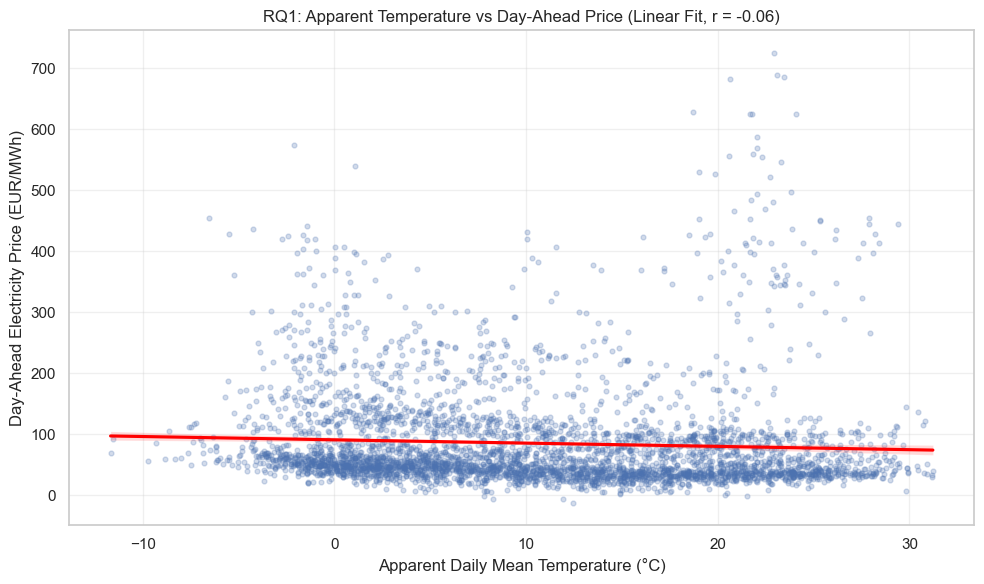

In [67]:
# --- Visualization: apparent temperature vs electricity price ---
plt.figure(figsize=(10, 6))
sns.regplot(
    data=rq1_data,
    x="apparent_temperature_mean",
    y="price_eur_mwh",
    scatter_kws={"alpha": 0.25, "s": 12},
    line_kws={"color": "red"}
)

plt.title(f"RQ1: Apparent Temperature vs Day-Ahead Price (Linear Fit, r = {corr_app:.2f})")
plt.xlabel("Apparent Daily Mean Temperature (°C)")
plt.ylabel("Day-Ahead Electricity Price (EUR/MWh)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

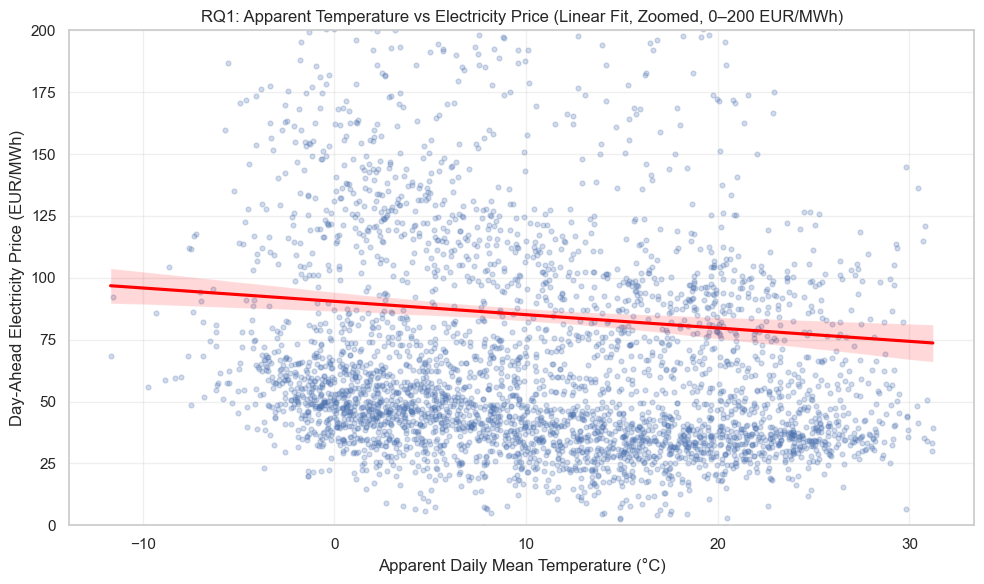

In [68]:
# --- Zoomed visualization: apparent temperature vs electricity price (0-200 EUR/MWh) ---
plt.figure(figsize=(10, 6))
sns.regplot(
    data=rq1_data,
    x="apparent_temperature_mean",
    y="price_eur_mwh",
    scatter_kws={"alpha": 0.25, "s": 12},
    line_kws={"color": "red"}
)

plt.ylim(0, 200)
plt.title(f"RQ1: Apparent Temperature vs Electricity Price (Linear Fit, Zoomed, 0–200 EUR/MWh)")
plt.xlabel("Apparent Daily Mean Temperature (°C)")
plt.ylabel("Day-Ahead Electricity Price (EUR/MWh)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Interpretation:**
The Pearson correlation analysis shows a **very weak negative linear relationship** between daily mean temperature and day-ahead electricity prices in Switzerland, with **r = -0.0455** and **p = 3.8883e-03**. For apparent (felt) temperature, the correlation is also **very weak and negative**, with **r = -0.0579** and **p = 2.4070e-04**. Both relationships are statistically significant at conventional significance levels, but their magnitude is very small, indicating that temperature alone explains only a negligible share of daily electricity price variation.

The comparison between actual and apparent temperature shows that apparent temperature is only slightly more strongly correlated with electricity prices than actual air temperature. However, the difference is marginal and does not change the overall conclusion: weather temperature by itself is not a meaningful standalone linear predictor of day-ahead electricity prices in Switzerland.

A likely explanation is that electricity prices are influenced by many additional factors, including fuel prices, hydropower availability, cross-border market conditions, CO₂ costs, and supply-demand imbalances. In addition, the scatter plots suggest substantial dispersion and possible non-linear effects, which cannot be captured by Pearson’s correlation coefficient alone.

**Conclusion:**
Since both p-values are below the 5% significance level, **H0₁** is rejected in favour of **H1₁**, meaning that a statistically significant linear correlation exists between temperature and day-ahead electricity prices in Switzerland. However, because the correlation coefficients are extremely close to zero, the practical relevance of this relationship is very limited. Overall, the results show that both actual and apparent temperature have only a **very weak negative linear association** with electricity prices and therefore provide only limited explanatory value on their own.

## 3. Research Question 2: Weather and Weekly Electricity Load
**RQ2:** How strongly do temperature and solar radiation explain weekly electricity load variability in Switzerland, measured by the coefficient of determination (*R²*) of a linear regression model?

- **H0₂:** Weekly mean temperature (actual and apparent) and solar radiation do not significantly explain variability in electricity load.
- **H1₂:** Weekly mean temperature (actual and apparent) and solar radiation significantly explain variability in electricity load.

The analysis is conducted with both actual mean temperature and apparent (felt) mean temperature. Multiple linear regression is used to assess explanatory power, measured by the coefficient of determination (*R²*).

In [69]:
# --- Prepare data for RQ2 ---
rq2_data = df_weekly[[
    "date",
    "load_end_users_ch_mw",
    "temperature_2m_mean",
    "apparent_temperature_mean",
    "shortwave_radiation_sum"
]].dropna().copy()
# --- Add quadratic temperature term ---
rq2_data["temperature_2m_mean_sq"] = rq2_data["temperature_2m_mean"] ** 2
rq2_data["apparent_temperature_mean_sq"] = rq2_data["apparent_temperature_mean"] ** 2

print(f"RQ2 dataset shape: {rq2_data.shape}")
display(rq2_data.head())

RQ2 dataset shape: (575, 7)


,date,load_end_users_ch_mw,temperature_2m_mean,apparent_temperature_mean,shortwave_radiation_sum,temperature_2m_mean_sq,apparent_temperature_mean_sq
0,2015-01-04,6473.11,6.85,-0.08,5.97,46.92,0.01
1,2015-01-11,7353.99,7.83,2.02,6.22,61.29,4.07
2,2015-01-18,7498.33,5.99,1.14,3.29,35.83,1.31
3,2015-01-25,7793.87,2.49,-1.97,5.48,6.18,3.87
4,2015-02-01,7818.88,3.17,-2.44,7.86,10.06,5.93


In [70]:
# --- Model 1: actual temperature + solar radiation ---
X_rq2_actual = rq2_data[["temperature_2m_mean", "shortwave_radiation_sum"]]
y_rq2 = rq2_data["load_end_users_ch_mw"]

model_rq2_actual = LinearRegression()
model_rq2_actual.fit(X_rq2_actual, y_rq2)

y_pred_rq2_actual = model_rq2_actual.predict(X_rq2_actual)
r2_actual = r2_score(y_rq2, y_pred_rq2_actual)

print("RQ2 – Model with Actual Temperature")
print(f"R²: {r2_actual:.4f}")
print(f"Intercept: {model_rq2_actual.intercept_:.2f}")
print(f"Coefficient (temperature_2m_mean): {model_rq2_actual.coef_[0]:.4f}")
print(f"Coefficient (shortwave_radiation_sum): {model_rq2_actual.coef_[1]:.4f}")

RQ2 – Model with Actual Temperature
R²: 0.8001
Intercept: 7770.07
Coefficient (temperature_2m_mean): -88.3977
Coefficient (shortwave_radiation_sum): -17.2091


In [71]:
# --- Model 2: apparent temperature + solar radiation ---
X_rq2_apparent = rq2_data[["apparent_temperature_mean", "shortwave_radiation_sum"]]

model_rq2_apparent = LinearRegression()
model_rq2_apparent.fit(X_rq2_apparent, y_rq2)

y_pred_rq2_apparent = model_rq2_apparent.predict(X_rq2_apparent)
r2_apparent = r2_score(y_rq2, y_pred_rq2_apparent)

print("RQ2 – Model with Apparent Temperature")
print(f"R²: {r2_apparent:.4f}")
print(f"Intercept: {model_rq2_apparent.intercept_:.2f}")
print(f"Coefficient (apparent_temperature_mean): {model_rq2_apparent.coef_[0]:.4f}")
print(f"Coefficient (shortwave_radiation_sum): {model_rq2_apparent.coef_[1]:.4f}")

RQ2 – Model with Apparent Temperature
R²: 0.8027
Intercept: 7336.42
Coefficient (apparent_temperature_mean): -68.0027
Coefficient (shortwave_radiation_sum): -21.6820


In [72]:
# --- Compare RQ2 models ---
rq2_results = pd.DataFrame({
    "model": [
        "Actual temperature + solar radiation",
        "Apparent temperature + solar radiation"
    ],
    "r2": [r2_actual, r2_apparent]
})

display(rq2_results)

,model,r2
0,Actual temperature + solar radiation,0.80
1,Apparent temperature + solar radiation,0.80


In [73]:
# --- Model 3: actual temperature + temperature squared + solar radiation ---
X_rq2_actual_quad = rq2_data[[
    "temperature_2m_mean",
    "temperature_2m_mean_sq",
    "shortwave_radiation_sum"
]]

model_rq2_actual_quad = LinearRegression()
model_rq2_actual_quad.fit(X_rq2_actual_quad, y_rq2)

y_pred_rq2_actual_quad = model_rq2_actual_quad.predict(X_rq2_actual_quad)
r2_actual_quad = r2_score(y_rq2, y_pred_rq2_actual_quad)

print("RQ2 – Quadratic Model with Actual Temperature")
print(f"R²: {r2_actual_quad:.4f}")
print(f"Intercept: {model_rq2_actual_quad.intercept_:.2f}")
print(f"Coefficient (temperature_2m_mean): {model_rq2_actual_quad.coef_[0]:.4f}")
print(f"Coefficient (temperature_2m_mean_sq): {model_rq2_actual_quad.coef_[1]:.4f}")
print(f"Coefficient (shortwave_radiation_sum): {model_rq2_actual_quad.coef_[2]:.4f}")

# --- Model 4: apparent temperature + temperature squared + solar radiation ---
X_rq2_apparent_quad = rq2_data[[
    "apparent_temperature_mean",
    "apparent_temperature_mean_sq",
    "shortwave_radiation_sum"
]]

model_rq2_apparent_quad = LinearRegression()
model_rq2_apparent_quad.fit(X_rq2_apparent_quad, y_rq2)

y_pred_rq2_apparent_quad = model_rq2_apparent_quad.predict(X_rq2_apparent_quad)
r2_apparent_quad = r2_score(y_rq2, y_pred_rq2_apparent_quad)

print("\nRQ2 – Quadratic Model with Apparent Temperature")
print(f"R²: {r2_apparent_quad:.4f}")
print(f"Intercept: {model_rq2_apparent_quad.intercept_:.2f}")
print(f"Coefficient (apparent_temperature_mean): {model_rq2_apparent_quad.coef_[0]:.4f}")
print(f"Coefficient (apparent_temperature_mean_sq): {model_rq2_apparent_quad.coef_[1]:.4f}")
print(f"Coefficient (shortwave_radiation_sum): {model_rq2_apparent_quad.coef_[2]:.4f}")

RQ2 – Quadratic Model with Actual Temperature
R²: 0.8574
Intercept: 8459.95
Coefficient (temperature_2m_mean): -215.5197
Coefficient (temperature_2m_mean_sq): 4.4560
Coefficient (shortwave_radiation_sum): -17.3282

RQ2 – Quadratic Model with Apparent Temperature
R²: 0.8735
Intercept: 7505.20
Coefficient (apparent_temperature_mean): -137.7986
Coefficient (apparent_temperature_mean_sq): 3.0896
Coefficient (shortwave_radiation_sum): -22.6005


**RQ2 – Quadratic Model Findings:**
Adding a quadratic temperature term substantially improves model performance compared
to the linear baseline. The R² increases from 0.8001 to 0.8574 for the actual
temperature model, and from 0.8027 to 0.8735 for the apparent temperature model.
This improvement confirms that the relationship between temperature and weekly
electricity load is not purely linear — electricity demand is high both in winter
(heating) and in summer (cooling), creating a U-shaped pattern that a linear model
cannot capture but a quadratic term can.

The positive coefficient on the squared temperature term (actual: 4.4560,
apparent: 3.0896) confirms the U-shaped relationship: load decreases as temperature
rises from cold levels, reaches a minimum at moderate temperatures, and increases
again at high temperatures. The apparent temperature quadratic model achieves the
highest explanatory power (R² = 0.8735) and is therefore considered the preferred
model for RQ2.

The assumption checks confirm that the quadratic models are a better fit: the
U-shaped pattern in the residuals vs. fitted plots has largely disappeared, and
the homoscedasticity assumption is now considered sufficiently satisfied.

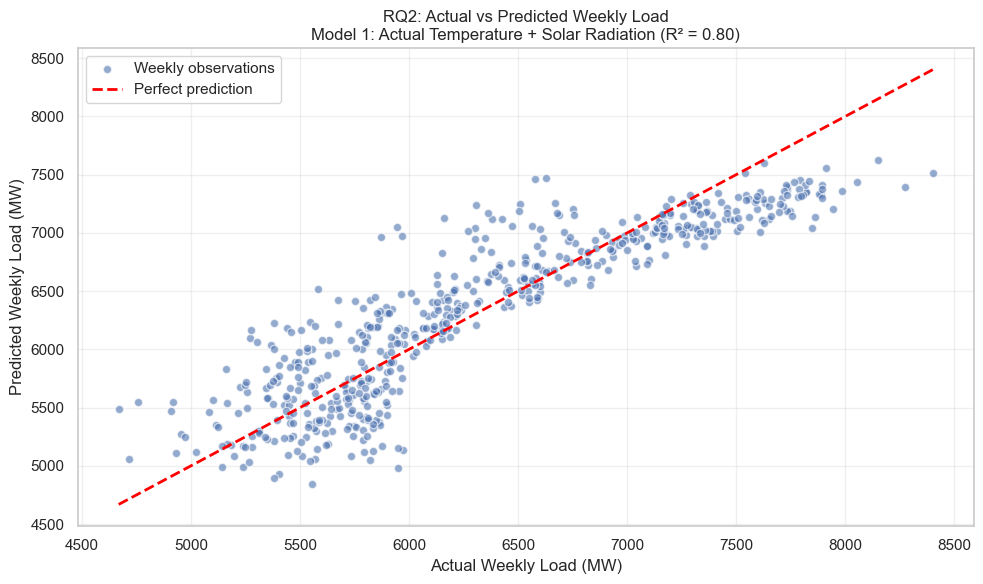

In [74]:
# --- Visualization: Actual vs Predicted Weekly Load (Model 1) ---
plt.figure(figsize=(10, 6))
plt.scatter(y_rq2, y_pred_rq2_actual, alpha=0.6, edgecolors="w", label="Weekly observations")

plt.plot(
    [y_rq2.min(), y_rq2.max()],
    [y_rq2.min(), y_rq2.max()],
    linestyle="--",
    linewidth=2,
    color="red",
    label="Perfect prediction"
)

plt.title(f"RQ2: Actual vs Predicted Weekly Load\nModel 1: Actual Temperature + Solar Radiation (R² = {r2_actual:.2f})")
plt.xlabel("Actual Weekly Load (MW)")
plt.ylabel("Predicted Weekly Load (MW)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

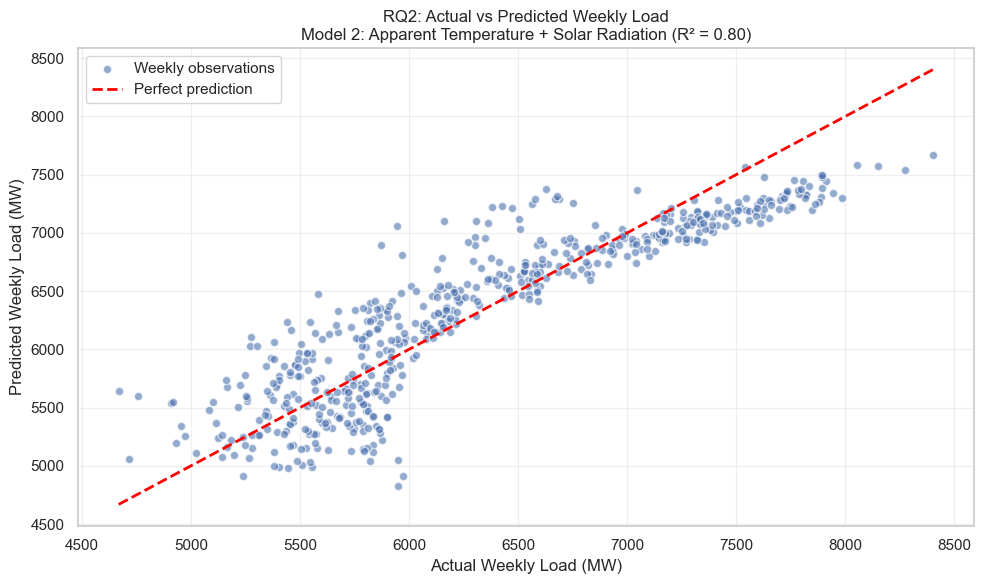

In [75]:
# --- Visualization: Actual vs Predicted Weekly Load (Model 2) ---
plt.figure(figsize=(10, 6))
plt.scatter(y_rq2, y_pred_rq2_apparent, alpha=0.6, edgecolors="w", label="Weekly observations")

plt.plot(
    [y_rq2.min(), y_rq2.max()],
    [y_rq2.min(), y_rq2.max()],
    linestyle="--",
    linewidth=2,
    color="red",
    label="Perfect prediction"
)

plt.title(f"RQ2: Actual vs Predicted Weekly Load\nModel 2: Apparent Temperature + Solar Radiation (R² = {r2_apparent:.2f})")
plt.xlabel("Actual Weekly Load (MW)")
plt.ylabel("Predicted Weekly Load (MW)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

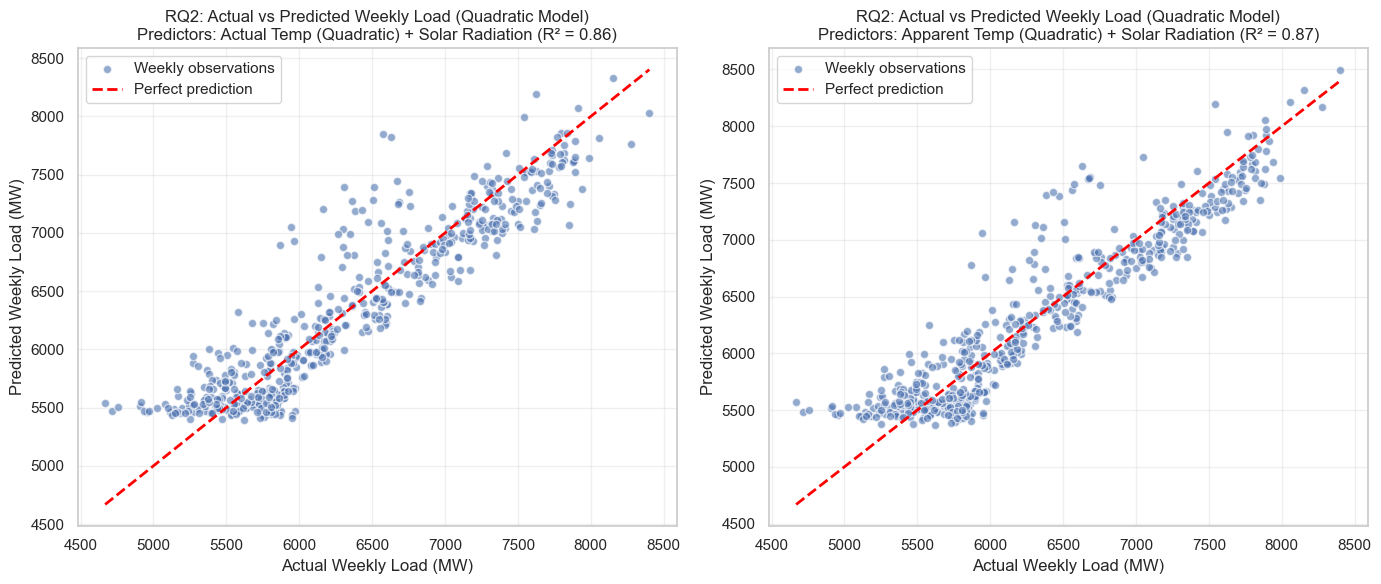

Figure saved.


In [76]:
# --- Visualization: Actual vs Predicted Weekly Load (Quadratic Models) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, y_pred, r2, label in zip(
    axes,
    [y_pred_rq2_actual_quad, y_pred_rq2_apparent_quad],
    [r2_actual_quad, r2_apparent_quad],
    ["Actual Temp (Quadratic) + Solar Radiation", "Apparent Temp (Quadratic) + Solar Radiation"]
):
    ax.scatter(y_rq2, y_pred, alpha=0.6, edgecolors="w", label="Weekly observations")
    ax.plot(
        [y_rq2.min(), y_rq2.max()],
        [y_rq2.min(), y_rq2.max()],
        linestyle="--", linewidth=2, color="red", label="Perfect prediction"
    )
    ax.set_title(f"RQ2: Actual vs Predicted Weekly Load (Quadratic Model)\nPredictors: {label} (R² = {r2:.2f})")
    ax.set_xlabel("Actual Weekly Load (MW)")
    ax.set_ylabel("Predicted Weekly Load (MW)")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../figures/rq2_actual_vs_predicted_quadratic.png", dpi=150)
plt.show()
print("Figure saved.")

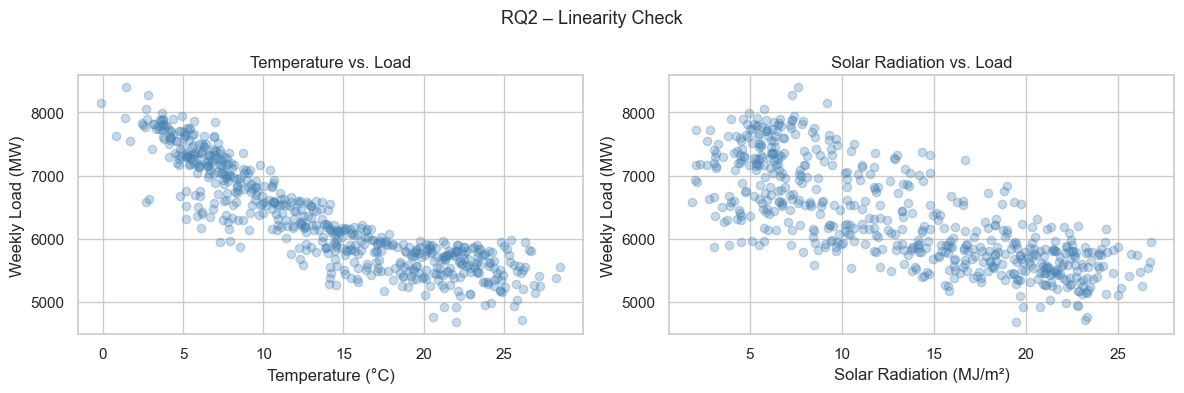

Figure saved.


In [77]:
# --- Assumption Check RQ2: Linearity ---
# Scatter plots of each predictor against the target variable

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(rq2_data["temperature_2m_mean"], y_rq2, alpha=0.3, color="steelblue")
axes[0].set_xlabel("Temperature (°C)")
axes[0].set_ylabel("Weekly Load (MW)")
axes[0].set_title("Temperature vs. Load")

axes[1].scatter(rq2_data["shortwave_radiation_sum"], y_rq2, alpha=0.3, color="steelblue")
axes[1].set_xlabel("Solar Radiation (MJ/m²)")
axes[1].set_ylabel("Weekly Load (MW)")
axes[1].set_title("Solar Radiation vs. Load")

plt.suptitle("RQ2 – Linearity Check", fontsize=13)
plt.tight_layout()
plt.savefig("../figures/rq2_linearity_check.png", dpi=150)
plt.show()
print("Figure saved.")

**Linearity findings (RQ2):**
Both scatter plots suggest an approximately linear relationship between the predictors
and weekly electricity load. Temperature shows a clear negative linear trend, indicating
that higher temperatures are associated with lower electricity demand. Solar radiation
also displays a negative linear association, though with considerably wider variance,
suggesting that other factors contribute to the spread. Overall, the linearity
assumption is considered satisfied for both predictors.

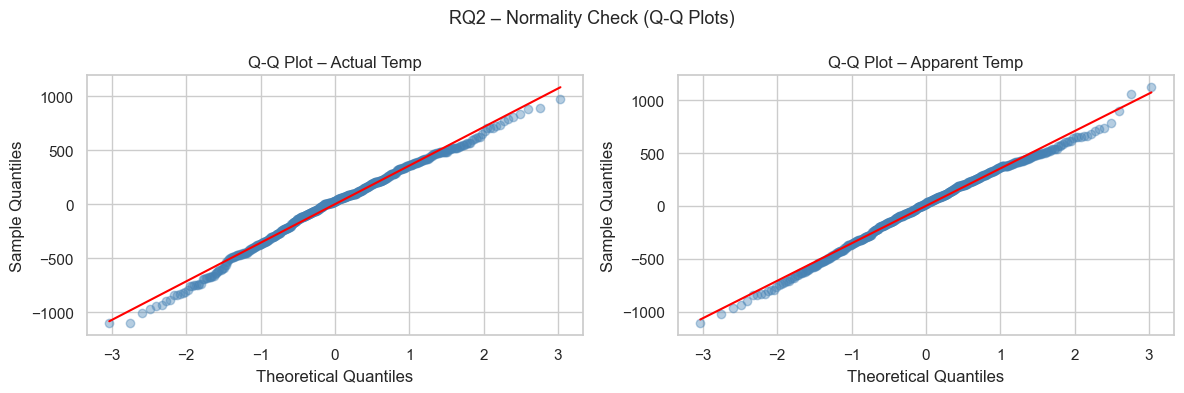

Shapiro-Wilk (Actual Temp): W=0.9913, p=0.0019
Shapiro-Wilk (Apparent Temp): W=0.9932, p=0.0109


In [78]:
# --- Assumption Check RQ2: Normality of Residuals ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

residuals_actual   = y_rq2 - y_pred_rq2_actual
residuals_apparent = y_rq2 - y_pred_rq2_apparent

for ax, residuals, label in zip(axes,
                                [residuals_actual, residuals_apparent],
                                ["Actual Temp", "Apparent Temp"]):
    (osm, osr), (slope, intercept, r) = stats.probplot(residuals, dist="norm")
    ax.plot(osm, osr, "o", alpha=0.4, color="steelblue")
    ax.plot(osm, slope * np.array(osm) + intercept, color="red", linewidth=1.5)
    ax.set_title(f"Q-Q Plot – {label}")
    ax.set_xlabel("Theoretical Quantiles")
    ax.set_ylabel("Sample Quantiles")

plt.suptitle("RQ2 – Normality Check (Q-Q Plots)", fontsize=13)
plt.tight_layout()
plt.savefig("../figures/rq2_normality_check.png", dpi=150)
plt.show()

# Shapiro-Wilk Test
for residuals, label in zip([residuals_actual, residuals_apparent],
                             ["Actual Temp", "Apparent Temp"]):
    stat, p = shapiro(residuals)
    print(f"Shapiro-Wilk ({label}): W={stat:.4f}, p={p:.4f}")

**Normality findings (RQ2):**
The Q-Q plots show that the residuals follow the theoretical normal distribution
closely in the central range, with only minor deviations at the tails. The
Shapiro-Wilk test formally rejects normality for both models (Actual Temp:
W=0.9913, p=0.0019; Apparent Temp: W=0.9932, p=0.0109). However, given the
sample size of n=575, the test is sensitive to small deviations. The visual
inspection suggests that the residuals are approximately normal, and the
assumption is considered sufficiently satisfied for practical purposes.

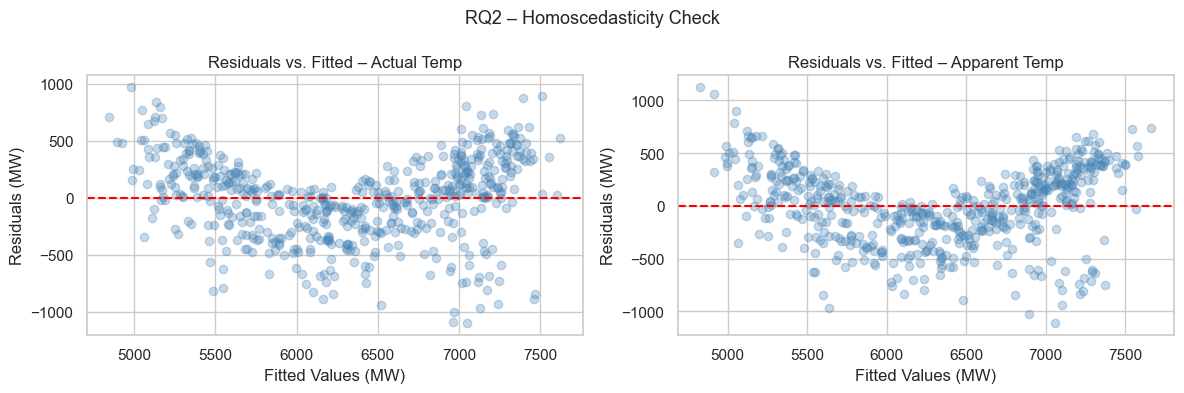

Figure saved.


In [79]:
# --- Assumption Check RQ2: Homoscedasticity ---
# Residuals vs. Fitted Values plot

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, residuals, y_pred, label in zip(
    axes,
    [residuals_actual, residuals_apparent],
    [y_pred_rq2_actual, y_pred_rq2_apparent],
    ["Actual Temp", "Apparent Temp"]
):
    ax.scatter(y_pred, residuals, alpha=0.3, color="steelblue")
    ax.axhline(0, color="red", linewidth=1.5, linestyle="--")
    ax.set_xlabel("Fitted Values (MW)")
    ax.set_ylabel("Residuals (MW)")
    ax.set_title(f"Residuals vs. Fitted – {label}")

plt.suptitle("RQ2 – Homoscedasticity Check", fontsize=13)
plt.tight_layout()
plt.savefig("../figures/rq2_homoscedasticity_check.png", dpi=150)
plt.show()
print("Figure saved.")


**Homoscedasticity findings (RQ2):**
Both residuals vs. fitted plots reveal a slight U-shaped pattern, indicating that
the residuals are not randomly distributed around zero across all fitted values.
This suggests that the linear model does not fully capture the non-linear
relationship between weather variables and electricity load — likely because
electricity demand is driven by both heating in winter and cooling in summer,
creating a curved seasonal pattern. The homoscedasticity assumption is therefore
not fully satisfied. A non-linear model specification (e.g. adding a quadratic
temperature term) could potentially improve model fit.

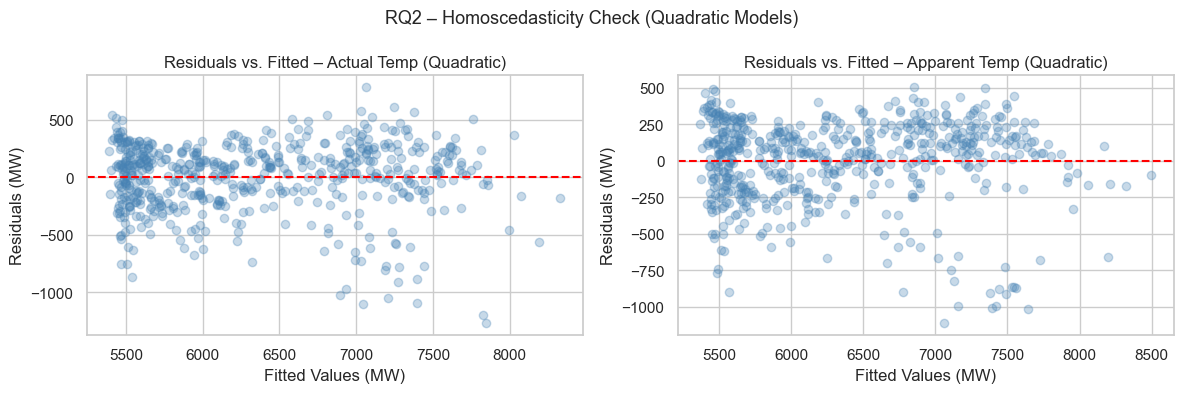

Figure saved.


In [80]:
# --- Homoscedasticity check for quadratic models ---
residuals_actual_quad   = y_rq2 - y_pred_rq2_actual_quad
residuals_apparent_quad = y_rq2 - y_pred_rq2_apparent_quad

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, residuals, y_pred, label in zip(
    axes,
    [residuals_actual_quad, residuals_apparent_quad],
    [y_pred_rq2_actual_quad, y_pred_rq2_apparent_quad],
    ["Actual Temp (Quadratic)", "Apparent Temp (Quadratic)"]
):
    ax.scatter(y_pred, residuals, alpha=0.3, color="steelblue")
    ax.axhline(0, color="red", linewidth=1.5, linestyle="--")
    ax.set_xlabel("Fitted Values (MW)")
    ax.set_ylabel("Residuals (MW)")
    ax.set_title(f"Residuals vs. Fitted – {label}")

plt.suptitle("RQ2 – Homoscedasticity Check (Quadratic Models)", fontsize=13)
plt.tight_layout()
plt.savefig("../figures/rq2_homoscedasticity_quadratic.png", dpi=150)
plt.show()
print("Figure saved.")

**Homoscedasticity check – Quadratic Models (RQ2):**
Adding a quadratic temperature term substantially improves the residual distribution
compared to the linear models. The U-shaped pattern observed in the linear models
has largely disappeared in both quadratic models, with residuals now distributed
more randomly around zero across the full range of fitted values. The apparent
temperature quadratic model shows a particularly even spread. While some
heteroscedasticity remains at the extremes, the homoscedasticity assumption is
considered sufficiently satisfied for practical purposes.

In [81]:
# --- Assumption Check RQ2: Multicollinearity (VIF) ---
from statsmodels.stats.outliers_influence import variance_inflation_factor

for X, label in zip(
    [X_rq2_actual, X_rq2_apparent],
    ["Actual Temp", "Apparent Temp"]
):
    vif_data = pd.DataFrame()
    vif_data["Feature"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i)
                       for i in range(X.shape[1])]
    print(f"VIF – {label}")
    print(vif_data.to_string(index=False))
    print()

VIF – Actual Temp
                Feature   VIF
    temperature_2m_mean 12.42
shortwave_radiation_sum 12.42

VIF – Apparent Temp
                  Feature  VIF
apparent_temperature_mean 5.92
  shortwave_radiation_sum 5.92



**Multicollinearity findings (RQ2):**
The VIF analysis reveals a notable difference between the two models. In the model
using actual temperature, both predictors show a VIF of 12.42, indicating problematic
multicollinearity. This is likely because temperature and solar radiation are
naturally correlated — sunny days tend to be warmer. In the model using apparent
temperature, the VIF drops to 5.92 for both predictors, which is borderline but
more acceptable. Overall, multicollinearity is a concern in the actual temperature
model and should be considered when interpreting the regression coefficients.

In [82]:
# --- Coefficient comparison table for RQ2 ---
rq2_coefficients = pd.DataFrame({
    "model": [
        "Actual temperature + solar radiation",
        "Apparent temperature + solar radiation"
    ],
    "intercept": [
        model_rq2_actual.intercept_,
        model_rq2_apparent.intercept_
    ],
    "temperature_coefficient": [
        model_rq2_actual.coef_[0],
        model_rq2_apparent.coef_[0]
    ],
    "solar_radiation_coefficient": [
        model_rq2_actual.coef_[1],
        model_rq2_apparent.coef_[1]
    ],
    "r2": [
        r2_actual,
        r2_apparent
    ]
})

display(rq2_coefficients)

,model,intercept,temperature_coefficient,solar_radiation_coefficient,r2
0,Actual temperature + solar radiation,7770.07,-88.40,-17.21,0.80
1,Apparent temperature + solar radiation,7336.42,-68.00,-21.68,0.80


**Interpretation:**
The multiple linear regression model using actual temperature and solar radiation explains a substantial share of weekly electricity load variability in Switzerland, with an R² = 0.8001. However, residual analysis revealed a U-shaped pattern in the residuals vs. fitted plot, indicating a violation of the linearity assumption: the true relationship between temperature and electricity load is non-linear, as demand is driven by both heating in winter and cooling in summer. A quadratic temperature term was therefore added, improving R² from 0.8001 to 0.8574 (actual temperature) and from 0.8027 to 0.8735 (apparent temperature), while largely resolving the residual pattern.

The quadratic models are therefore considered the preferred specification for RQ2. The positive coefficient on the squared temperature term confirms the U-shaped relationship: load decreases as temperatures rise from cold levels, reaches a minimum at moderate temperatures, and increases again at high temperatures.

The estimated coefficients show a negative linear temperature effect in both models, meaning that moving away from extreme cold towards moderate temperatures reduces electricity demand. Solar radiation also exhibits a negative effect, likely reflecting seasonal patterns where higher radiation coincides with lower overall energy demand. Both actual and apparent temperature yield very similar results, suggesting that the two variables contain largely overlapping information.

The scatter plots of actual versus predicted values confirm a strong model fit for the quadratic models, with most observations lying close to the 45-degree line. Some deviations remain at extreme load values, indicating that not all underlying drivers are captured. Important factors such as calendar effects (e.g., public holidays), economic activity, and additional weather variables are not included. Furthermore, the R² values reported here are in-sample metrics, as no train/test split was applied for RQ2 — the true out-of-sample predictive accuracy may therefore be lower.

**Conclusion:**
The results support **H1₂**, as temperature and solar radiation explain a substantial share of weekly electricity load variability in Switzerland. The high R² values (~0.87) indicate that weather conditions are key drivers of electricity demand at the weekly level.

The comparison between actual and apparent temperature shows only a marginal difference in explanatory power, suggesting that both variables capture similar underlying effects. Overall, the findings confirm that weather variables significantly influence electricity load, although further improvements could be achieved by incorporating additional explanatory factors.

## 4. Research Question 3: Predictive Modeling of Electricity Prices
**RQ3:** How accurately can weather variables predict day-ahead electricity prices in Switzerland, evaluated by a regression model trained on 2015–2022 data and tested on 2023-2025 data?

- **H0₃:** A model using weather variables does not achieve better predictive accuracy than a baseline model.
- **H1₃:** A model using weather variables achieves better predictive accuracy than a baseline model, measured by a lower mean absolute error (*MAE*) on the 2023-2025 test set.

The predictive analysis includes both actual temperature and apparent (felt) temperature. Model performance is evaluated out-of-sample using the mean absolute error (*MAE*) on the 2023-2025 test set and compared against a simple baseline model.

In [83]:
# --- Prepare data for RQ3 ---
rq3_data = df_daily[[
    "date",
    "year",
    "price_eur_mwh",
    "temperature_2m_mean",
    "apparent_temperature_mean",
    "windspeed_10m_max",
    "cloudcover_mean"
]].dropna().copy()

train_rq3 = rq3_data[rq3_data["year"] < 2023].copy()
test_rq3  = rq3_data[rq3_data["year"] >= 2023].copy()

print(f"RQ3 full dataset shape: {rq3_data.shape}")
print(f"Training set shape (2015–2022): {train_rq3.shape}")
print(f"Test set shape (2023- 2025): {test_rq3.shape}")

display(train_rq3.head())
display(test_rq3.head())

RQ3 full dataset shape: (4017, 7)
Training set shape (2015–2022): (2922, 7)
Test set shape (2023- 2025): (1095, 7)


,date,year,price_eur_mwh,temperature_2m_mean,apparent_temperature_mean,windspeed_10m_max,cloudcover_mean
0,2015-01-01,2015,36.63,4.00,-3.35,6.30,7.00
1,2015-01-02,2015,41.61,6.40,-1.45,10.50,71.00
2,2015-01-03,2015,36.59,9.40,2.55,12.30,56.00
3,2015-01-04,2015,31.72,7.60,1.92,13.00,13.00
4,2015-01-05,2015,47.39,6.70,-0.82,12.20,6.00


,date,year,price_eur_mwh,temperature_2m_mean,apparent_temperature_mean,windspeed_10m_max,cloudcover_mean
2922,2023-01-01,2023,6.57,9.80,7.95,4.00,100.00
2923,2023-01-02,2023,104.97,10.20,7.30,4.00,100.00
2924,2023-01-03,2023,154.01,9.60,6.53,4.00,91.00
2925,2023-01-04,2023,137.24,7.10,3.82,5.00,93.00
2926,2023-01-05,2023,140.68,8.00,6.42,9.40,62.00


In [84]:
# --- Baseline model: predict the mean training price for all 2023-2025 observations ---
baseline_mean_price = train_rq3["price_eur_mwh"].mean()
baseline_pred = np.full(shape=len(test_rq3), fill_value=baseline_mean_price)

mae_baseline = mean_absolute_error(test_rq3["price_eur_mwh"], baseline_pred)

print("RQ3 – Baseline Model")
print(f"Training mean price: {baseline_mean_price:.2f} EUR/MWh")
print(f"Baseline MAE on 2023-2025 test set: {mae_baseline:.2f} EUR/MWh")

RQ3 – Baseline Model
Training mean price: 80.95 EUR/MWh
Baseline MAE on 2023-2025 test set: 30.17 EUR/MWh


In [85]:
# --- Model 1: actual temperature + wind speed + cloud cover ---
features_rq3_actual = ["temperature_2m_mean", "windspeed_10m_max", "cloudcover_mean"]
target_rq3 = "price_eur_mwh"

X_train_actual = train_rq3[features_rq3_actual]
X_test_actual  = test_rq3[features_rq3_actual]
y_train_rq3 = train_rq3[target_rq3]
y_test_rq3  = test_rq3[target_rq3]

model_rq3_actual = LinearRegression()
model_rq3_actual.fit(X_train_actual, y_train_rq3)

pred_rq3_actual = model_rq3_actual.predict(X_test_actual)
mae_rq3_actual = mean_absolute_error(y_test_rq3, pred_rq3_actual)

print("RQ3 – Model 1: Actual Temperature")
print(f"MAE on 2023-2025 test set: {mae_rq3_actual:.2f} EUR/MWh")
print(f"Intercept: {model_rq3_actual.intercept_:.2f}")
for feature, coef in zip(features_rq3_actual, model_rq3_actual.coef_):
    print(f"Coefficient ({feature}): {coef:.4f}")

RQ3 – Model 1: Actual Temperature
MAE on 2023-2025 test set: 30.87 EUR/MWh
Intercept: 73.84
Coefficient (temperature_2m_mean): 0.1815
Coefficient (windspeed_10m_max): 0.7288
Coefficient (cloudcover_mean): -0.0233


In [86]:
# --- Model 2: apparent temperature + wind speed + cloud cover ---
features_rq3_apparent = ["apparent_temperature_mean", "windspeed_10m_max", "cloudcover_mean"]

X_train_apparent = train_rq3[features_rq3_apparent]
X_test_apparent  = test_rq3[features_rq3_apparent]

model_rq3_apparent = LinearRegression()
model_rq3_apparent.fit(X_train_apparent, y_train_rq3)

pred_rq3_apparent = model_rq3_apparent.predict(X_test_apparent)
mae_rq3_apparent = mean_absolute_error(y_test_rq3, pred_rq3_apparent)

print("RQ3 – Model 2: Apparent Temperature")
print(f"MAE on 2023-2025 test set: {mae_rq3_apparent:.2f} EUR/MWh")
print(f"Intercept: {model_rq3_apparent.intercept_:.2f}")
for feature, coef in zip(features_rq3_apparent, model_rq3_apparent.coef_):
    print(f"Coefficient ({feature}): {coef:.4f}")

RQ3 – Model 2: Apparent Temperature
MAE on 2023-2025 test set: 30.47 EUR/MWh
Intercept: 76.89
Coefficient (apparent_temperature_mean): 0.0017
Coefficient (windspeed_10m_max): 0.6956
Coefficient (cloudcover_mean): -0.0291


In [87]:
# --- Compare RQ3 models ---
rq3_results = pd.DataFrame({
    "model": [
        "Baseline mean price",
        "Actual temperature + wind + cloud cover",
        "Apparent temperature + wind + cloud cover"
    ],
    "mae_test_2023-2025": [
        mae_baseline,
        mae_rq3_actual,
        mae_rq3_apparent
    ]
})

display(rq3_results.sort_values("mae_test_2023-2025"))

,model,mae_test_2023-2025
0,Baseline mean price,30.17
2,Apparent temperature + wind + cloud cover,30.47
1,Actual temperature + wind + cloud cover,30.87


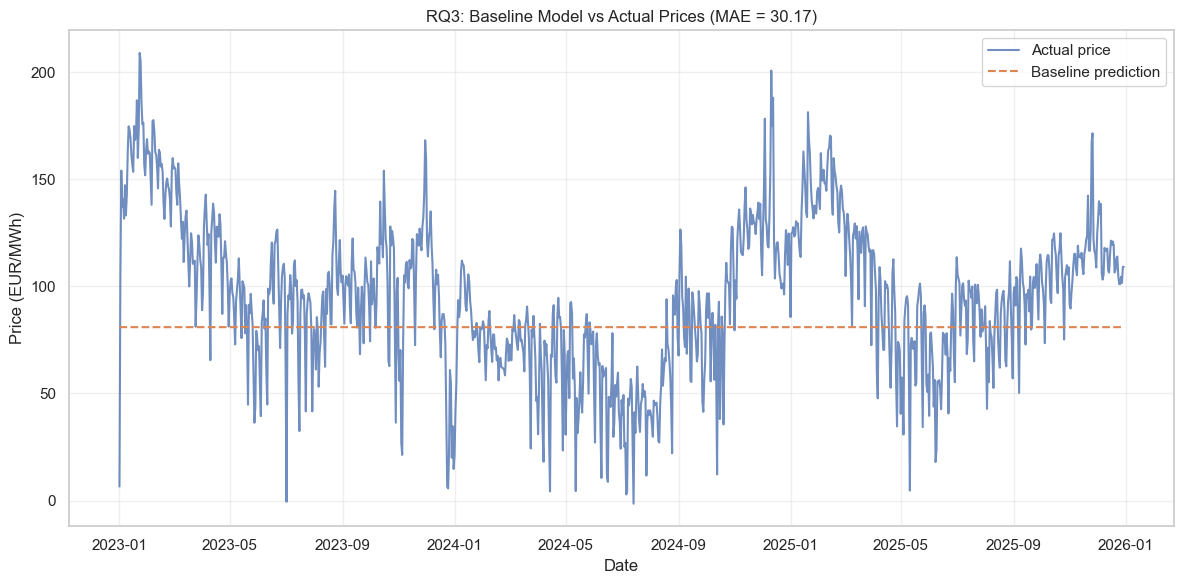

In [88]:
# --- Visualization: baseline prediction vs actual prices ---
plt.figure(figsize=(12, 6))
plt.plot(test_rq3["date"], y_test_rq3, label="Actual price", alpha=0.8)
plt.plot(test_rq3["date"], baseline_pred, label="Baseline prediction", linestyle="--")

plt.title(f"RQ3: Baseline Model vs Actual Prices (MAE = {mae_baseline:.2f})")
plt.xlabel("Date")
plt.ylabel("Price (EUR/MWh)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

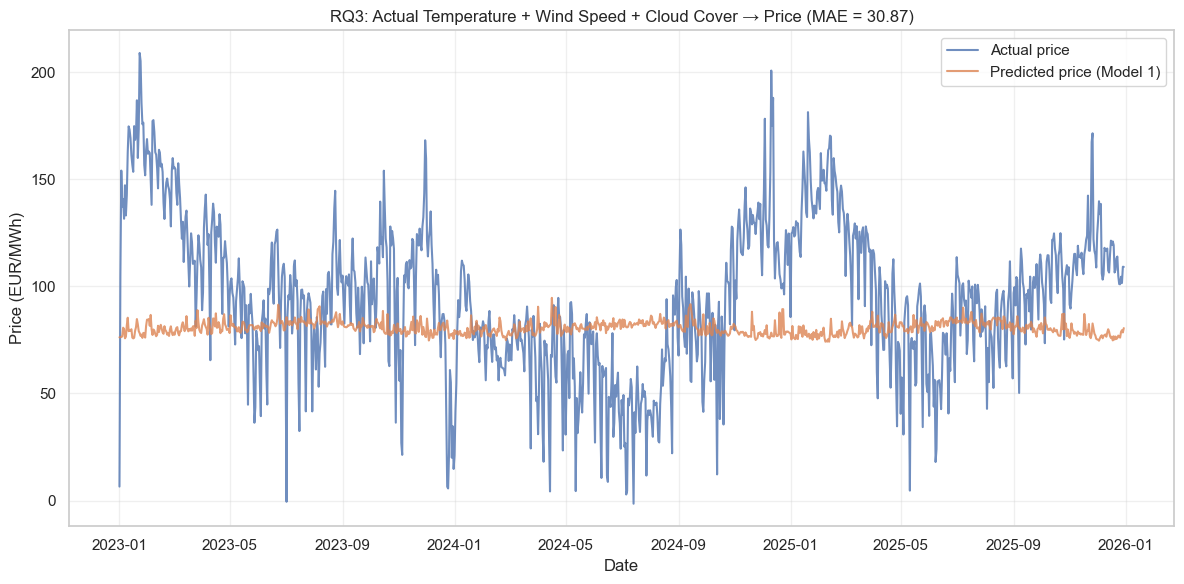

In [89]:
# --- Visualization: Model 1 prediction vs actual prices ---
plt.figure(figsize=(12, 6))
plt.plot(test_rq3["date"], y_test_rq3, label="Actual price", alpha=0.8)
plt.plot(test_rq3["date"], pred_rq3_actual, label="Predicted price (Model 1)", alpha=0.8)

plt.title(f"RQ3: Actual Temperature + Wind Speed + Cloud Cover → Price (MAE = {mae_rq3_actual:.2f})")
plt.xlabel("Date")
plt.ylabel("Price (EUR/MWh)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

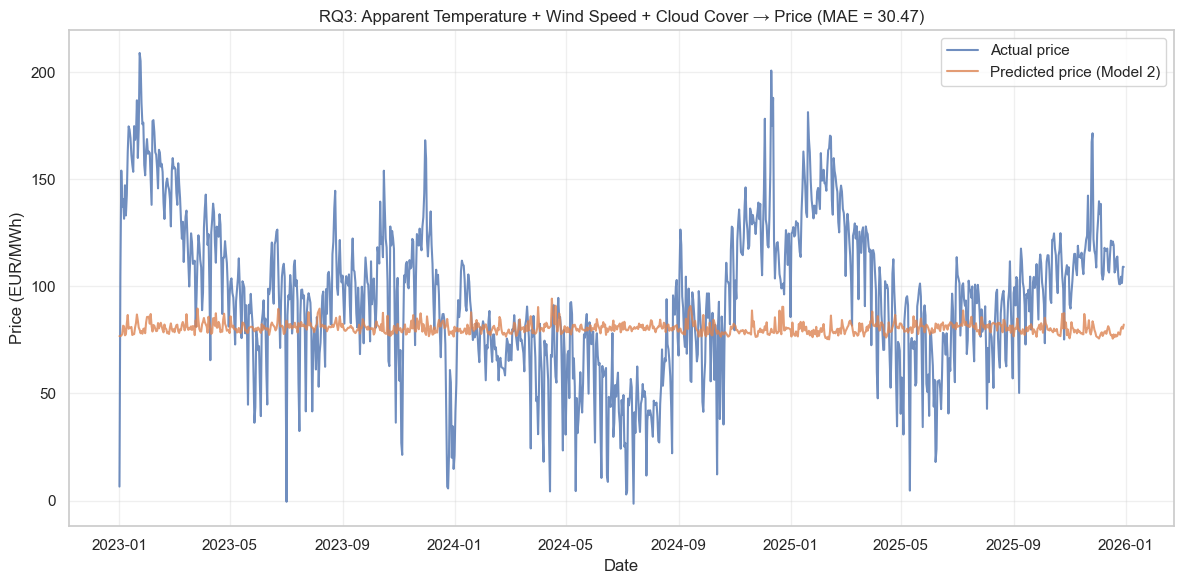

In [90]:
# --- Visualization: Model 2 prediction vs actual prices ---
plt.figure(figsize=(12, 6))
plt.plot(test_rq3["date"], y_test_rq3, label="Actual price", alpha=0.8)
plt.plot(test_rq3["date"], pred_rq3_apparent, label="Predicted price (Model 2)", alpha=0.8)

plt.title(f"RQ3: Apparent Temperature + Wind Speed + Cloud Cover → Price (MAE = {mae_rq3_apparent:.2f})")
plt.xlabel("Date")
plt.ylabel("Price (EUR/MWh)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

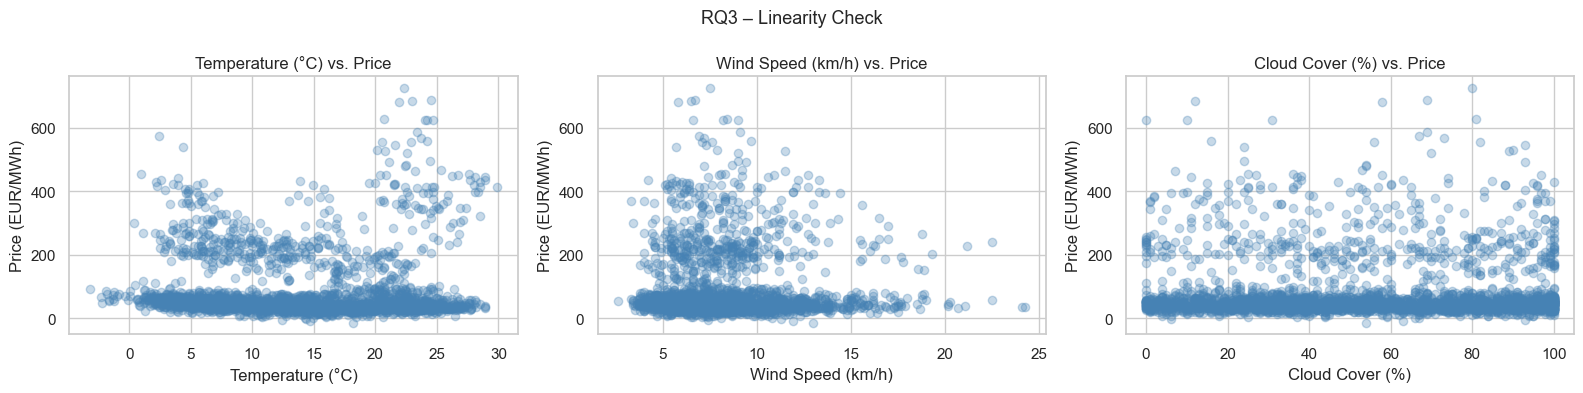

Figure saved.


In [91]:
# --- Assumption Check RQ3: Linearity ---
# Scatter plots of each predictor against the target variable

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, feature, label in zip(
    axes,
    ["temperature_2m_mean", "windspeed_10m_max", "cloudcover_mean"],
    ["Temperature (°C)", "Wind Speed (km/h)", "Cloud Cover (%)"]
):
    ax.scatter(train_rq3[feature], y_train_rq3, alpha=0.3, color="steelblue")
    ax.set_xlabel(label)
    ax.set_ylabel("Price (EUR/MWh)")
    ax.set_title(f"{label} vs. Price")

plt.suptitle("RQ3 – Linearity Check", fontsize=13)
plt.tight_layout()
plt.savefig("../figures/rq3_linearity_check.png", dpi=150)
plt.show()
print("Figure saved.")

**Linearity findings (RQ3):**
The scatter plots reveal no clear linear relationship between any of the three
predictors (temperature, wind speed, cloud cover) and day-ahead electricity prices.
All three plots show a wide dispersion of points with a dense cluster at low price
levels and extreme upward outliers corresponding to the 2021–2023 energy crisis.
This suggests that weather variables alone have very limited linear explanatory
power for electricity prices, and that the price is driven by additional
non-weather factors such as fuel costs and market conditions. The linearity
assumption is only weakly satisfied for this model.

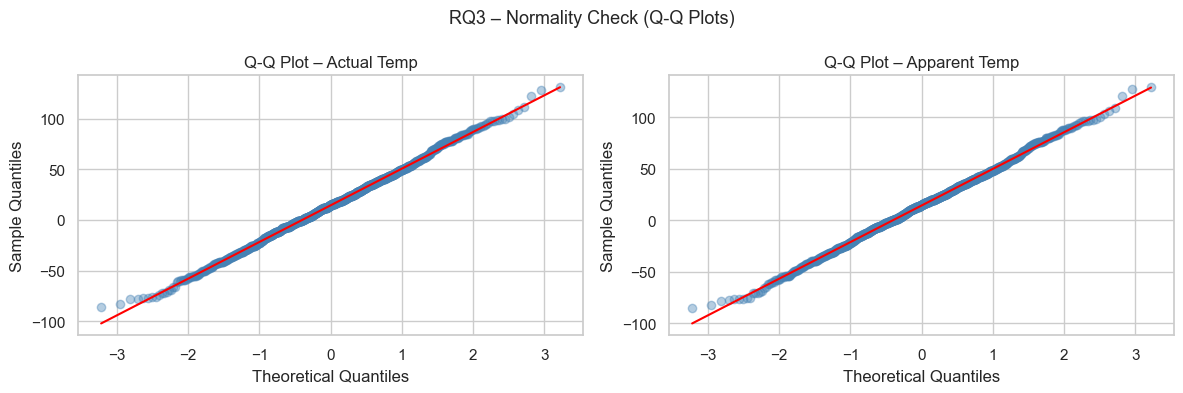

Shapiro-Wilk (Actual Temp): W=0.9984, p=0.4350
Shapiro-Wilk (Apparent Temp): W=0.9985, p=0.4654


In [92]:
# --- Assumption Check RQ3: Normality of Residuals ---
from scipy.stats import shapiro
import scipy.stats as stats

residuals_rq3_actual   = y_test_rq3 - pred_rq3_actual
residuals_rq3_apparent = y_test_rq3 - pred_rq3_apparent

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, residuals, label in zip(
    axes,
    [residuals_rq3_actual, residuals_rq3_apparent],
    ["Actual Temp", "Apparent Temp"]
):
    (osm, osr), (slope, intercept, r) = stats.probplot(residuals, dist="norm")
    ax.plot(osm, osr, "o", alpha=0.4, color="steelblue")
    ax.plot(osm, slope * np.array(osm) + intercept, color="red", linewidth=1.5)
    ax.set_title(f"Q-Q Plot – {label}")
    ax.set_xlabel("Theoretical Quantiles")
    ax.set_ylabel("Sample Quantiles")

plt.suptitle("RQ3 – Normality Check (Q-Q Plots)", fontsize=13)
plt.tight_layout()
plt.savefig("../figures/rq3_normality_check.png", dpi=150)
plt.show()

# Shapiro-Wilk Test
for residuals, label in zip(
    [residuals_rq3_actual, residuals_rq3_apparent],
    ["Actual Temp", "Apparent Temp"]
):
    stat, p = shapiro(residuals)
    print(f"Shapiro-Wilk ({label}): W={stat:.4f}, p={p:.4f}")

**Normality findings (RQ3):**
The Q-Q plots show that the residuals follow the theoretical normal distribution
very closely across the full range, with only negligible deviations at the tails.
The Shapiro-Wilk test confirms normality for both models (Actual Temp: W=0.9984,
p=0.4350; Apparent Temp: W=0.9985, p=0.4654). Both p-values are well above the
0.05 significance level, meaning the null hypothesis of normality cannot be
rejected. The normality assumption is clearly satisfied for RQ3.

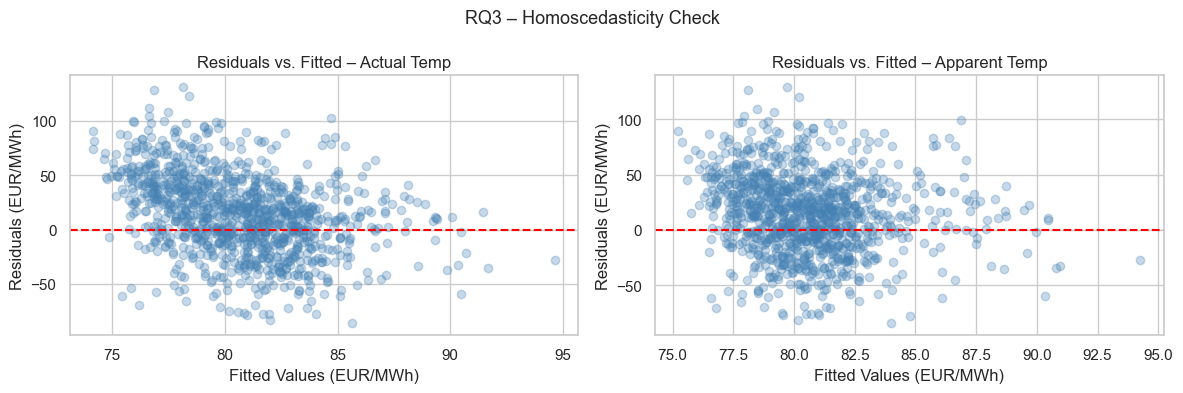

Figure saved.


In [93]:
# --- Assumption Check RQ3: Homoscedasticity ---
# Residuals vs. Fitted Values plot

residuals_rq3_actual   = y_test_rq3 - pred_rq3_actual
residuals_rq3_apparent = y_test_rq3 - pred_rq3_apparent

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, residuals, y_pred, label in zip(
    axes,
    [residuals_rq3_actual, residuals_rq3_apparent],
    [pred_rq3_actual, pred_rq3_apparent],
    ["Actual Temp", "Apparent Temp"]
):
    ax.scatter(y_pred, residuals, alpha=0.3, color="steelblue")
    ax.axhline(0, color="red", linewidth=1.5, linestyle="--")
    ax.set_xlabel("Fitted Values (EUR/MWh)")
    ax.set_ylabel("Residuals (EUR/MWh)")
    ax.set_title(f"Residuals vs. Fitted – {label}")

plt.suptitle("RQ3 – Homoscedasticity Check", fontsize=13)
plt.tight_layout()
plt.savefig("../figures/rq3_homoscedasticity_check.png", dpi=150)
plt.show()
print("Figure saved.")

**Homoscedasticity findings (RQ3):**
The residuals vs. fitted plots reveal two issues. First, the fitted values cluster
in a very narrow range (75–95 EUR/MWh), indicating that the model fails to capture
the extreme price spikes of the 2021–2023 energy crisis and essentially predicts
near the training mean for all observations. Second, the residuals show a clear
funnel shape, with larger deviations at the upper end — a sign of heteroscedasticity.
This means that the model systematically underestimates high prices and the variance
of residuals is not constant across fitted values. The homoscedasticity assumption
is not satisfied for RQ3.

In [94]:
# --- Assumption Check RQ3: Multicollinearity (VIF) ---
from statsmodels.stats.outliers_influence import variance_inflation_factor

for X, label in zip(
    [X_train_actual, X_train_apparent],
    ["Actual Temp", "Apparent Temp"]
):
    vif_data = pd.DataFrame()
    vif_data["Feature"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i)
                       for i in range(X.shape[1])]
    print(f"VIF – {label}")
    print(vif_data.to_string(index=False))
    print()

VIF – Actual Temp
            Feature  VIF
temperature_2m_mean 3.60
  windspeed_10m_max 3.98
    cloudcover_mean 2.80

VIF – Apparent Temp
                  Feature  VIF
apparent_temperature_mean 2.04
        windspeed_10m_max 3.01
          cloudcover_mean 2.72



**Multicollinearity findings (RQ3):**
The VIF analysis confirms no problematic multicollinearity in either model. For the
actual temperature model, all VIF values are well below 5 (temperature: 3.60,
wind speed: 3.98, cloud cover: 2.80). The apparent temperature model shows even
lower values (temperature: 2.04, wind speed: 3.01, cloud cover: 2.72). All
predictors can therefore be considered sufficiently independent, and the regression
coefficients are reliably interpretable. The multicollinearity assumption is
clearly satisfied for RQ3.

In [95]:
# --- Coefficient comparison table for RQ3 weather models ---
rq3_coefficients = pd.DataFrame({
    "model": [
        "Actual temperature + wind + cloud cover",
        "Apparent temperature + wind + cloud cover"
    ],
    "intercept": [
        model_rq3_actual.intercept_,
        model_rq3_apparent.intercept_
    ],
    "temperature_coefficient": [
        model_rq3_actual.coef_[0],
        model_rq3_apparent.coef_[0]
    ],
    "windspeed_coefficient": [
        model_rq3_actual.coef_[1],
        model_rq3_apparent.coef_[1]
    ],
    "cloudcover_coefficient": [
        model_rq3_actual.coef_[2],
        model_rq3_apparent.coef_[2]
    ],
    "mae_test_2023-2025": [
        mae_rq3_actual,
        mae_rq3_apparent
    ]
})

display(rq3_coefficients)

,model,intercept,temperature_coefficient,windspeed_coefficient,cloudcover_coefficient,mae_test_2023-2025
0,Actual temperature + wind + cloud cover,73.84,0.18,0.73,-0.02,30.87
1,Apparent temperature + wind + cloud cover,76.89,0.00,0.70,-0.03,30.47


### Extension: Improved Price Prediction Model

To explore whether predictive performance can be improved beyond the basic weather-only specification, an extended model is estimated. This model includes additional explanatory variables such as solar radiation, sunshine duration, electricity load, and a one-day lagged price. The purpose of this extension is to assess whether predictive accuracy improves when temporal dependence and broader market-related information are incorporated.

In [96]:
# --- Prepare extended dataset for improved model ---
rq3_ext = df_daily.copy()

rq3_ext["price_lag_1"] = rq3_ext["price_eur_mwh"].shift(1)
rq3_ext = rq3_ext.dropna().copy()

train_rq3_ext = rq3_ext[rq3_ext["year"] < 2023].copy()
test_rq3_ext  = rq3_ext[rq3_ext["year"] >= 2023].copy()

features_rq3_ext = [
    "temperature_2m_mean",
    "apparent_temperature_mean",
    "windspeed_10m_max",
    "cloudcover_mean",
    "shortwave_radiation_sum",
    "sunshine_duration",
    "load_end_users_ch_mw",
    "price_lag_1"
]

X_train_ext = train_rq3_ext[features_rq3_ext]
X_test_ext  = test_rq3_ext[features_rq3_ext]
y_train_ext = train_rq3_ext["price_eur_mwh"]
y_test_ext  = test_rq3_ext["price_eur_mwh"]

print(f"Extended training set shape: {train_rq3_ext.shape}")
print(f"Extended test set shape: {test_rq3_ext.shape}")

Extended training set shape: (2921, 23)
Extended test set shape: (1095, 23)


In [97]:
# --- Train and evaluate improved model ---
model_rq3_ext = LinearRegression()
model_rq3_ext.fit(X_train_ext, y_train_ext)

pred_rq3_ext = model_rq3_ext.predict(X_test_ext)
mae_rq3_ext = mean_absolute_error(y_test_ext, pred_rq3_ext)

print("RQ3 – Extended Model")
print(f"MAE on 2023-2025 test set: {mae_rq3_ext:.2f} EUR/MWh")

RQ3 – Extended Model
MAE on 2023-2025 test set: 11.93 EUR/MWh


In [98]:
# --- Compare all RQ3 models including extension ---
rq3_all_results = pd.DataFrame({
    "model": [
        "Baseline mean price",
        "Actual temperature + wind + cloud cover",
        "Apparent temperature + wind + cloud cover",
        "Extended model with lag/load/weather"
    ],
    "mae_test_2023-2025": [
        mae_baseline,
        mae_rq3_actual,
        mae_rq3_apparent,
        mae_rq3_ext
    ]
})

display(rq3_all_results.sort_values("mae_test_2023-2025"))

,model,mae_test_2023-2025
3,Extended model with lag/load/weather,11.93
0,Baseline mean price,30.17
2,Apparent temperature + wind + cloud cover,30.47
1,Actual temperature + wind + cloud cover,30.87


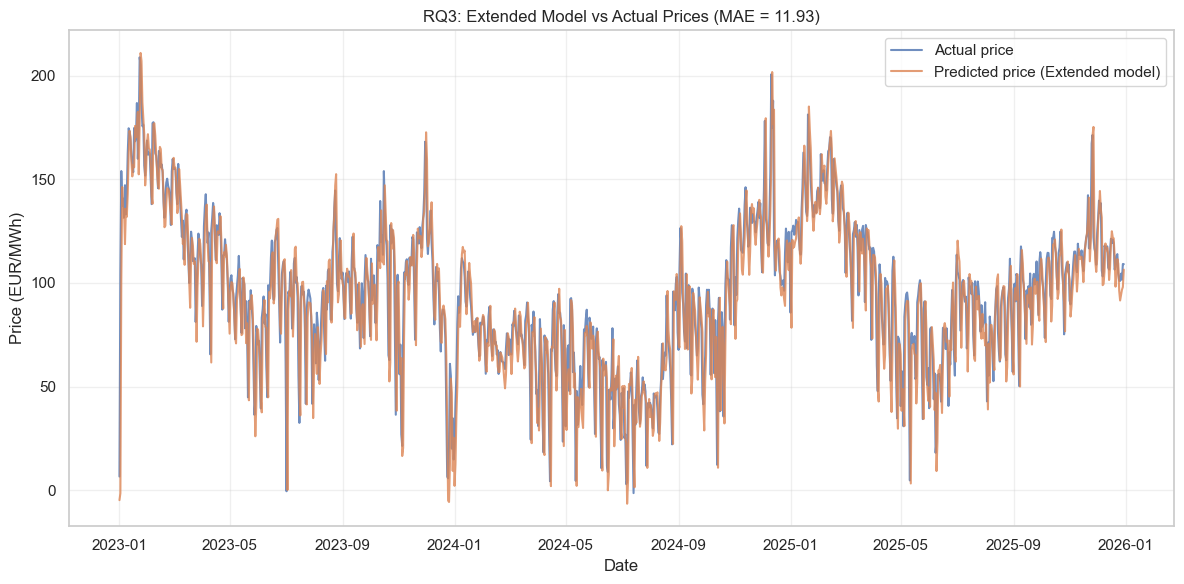

In [99]:
# --- Visualization: Extended model prediction vs actual prices ---
plt.figure(figsize=(12, 6))
plt.plot(test_rq3_ext["date"], y_test_ext, label="Actual price", alpha=0.8)
plt.plot(test_rq3_ext["date"], pred_rq3_ext, label="Predicted price (Extended model)", alpha=0.8)

plt.title(f"RQ3: Extended Model vs Actual Prices (MAE = {mae_rq3_ext:.2f})")
plt.xlabel("Date")
plt.ylabel("Price (EUR/MWh)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Interpretation:**
The baseline model, which predicts the mean electricity price from the training period for all observations in the 2023–2025 test set, achieves an **MAE of 30.17 EUR/MWh**. This serves as the reference point for evaluating whether weather variables improve predictive performance.

The weather-only regression models do **not** outperform the baseline. The model using **actual temperature, wind speed, and cloud cover** yields an **MAE of 30.87 EUR/MWh**, while the model using **apparent temperature, wind speed, and cloud cover** performs slightly better but still worse than the baseline, with an **MAE of 30.47 EUR/MWh**. This indicates that these weather variables alone do not provide sufficient information to accurately predict day-ahead electricity prices in Switzerland over the 2023–2025 period.

The coefficient estimates also suggest only a limited role for temperature in the weather-only models. In the model with actual temperature, the temperature coefficient is very small (**0.1815**), and in the apparent temperature model it is almost zero (**0.0017**). Wind speed has a modest positive coefficient in both models, while cloud cover has a very small negative coefficient. Overall, the predicted price series of both weather-only models are overly smooth and remain close to the average price level, failing to capture the strong fluctuations and spikes visible in the actual market prices.

This pattern indicates **underfitting**. The weather-only models are too simple to represent the complex dynamics of electricity prices, which are influenced not only by weather but also by additional factors such as fuel prices, hydropower availability, cross-border market conditions, supply constraints, and temporal dependencies. As a result, the models fail to capture important variation in the target variable.

The extended model, which includes additional variables such as solar radiation, sunshine duration, electricity load, and a one-day lagged price, performs substantially better and achieves an **MAE of 11.93 EUR/MWh** on the 2023–2025 test set. This large improvement shows that predictive performance increases strongly when temporal structure and broader system information are incorporated. The prediction plot also confirms that the extended model follows the actual price series much more closely than the simpler weather-only models.

However, this improved performance should be interpreted with caution. The inclusion of the lagged price variable introduces strong autocorrelation into the model and allows it to exploit the persistence of electricity prices over time. This is useful for prediction, but it means the model may rely more on temporal dependence than on genuinely explaining price formation through underlying market drivers. Therefore, while the extended model does not show obvious signs of underfitting, its strong performance does not necessarily imply a fully explanatory model of electricity prices.

**Conclusion:**
The results do **not** support **H1₃** for the basic weather-only models. Since both weather-based regression models have a higher MAE than the baseline model, **H0₃ cannot be rejected**. In other words, temperature, wind speed, and cloud cover alone do not improve predictive accuracy for day-ahead electricity prices in Switzerland over the 2023–2025 test period.

At the same time, the extended model shows that predictive accuracy can be improved substantially when additional variables are included. With an **MAE of 11.93 EUR/MWh**, it clearly outperforms both the baseline and the weather-only models. This suggests that electricity price prediction benefits strongly from including lagged prices and broader explanatory variables beyond simple weather indicators.

A key limitation of the analysis is that the simple weather-only models omit important market factors and are therefore likely **underfitted**. For the extended model, there is no clear evidence of overfitting because performance is evaluated on a held-out test period. However, the strong contribution of the lagged price variable means that the model may depend heavily on autocorrelation, which can make its predictive success appear stronger than its true explanatory power. Future work should therefore test additional market variables and more advanced time-series methods to improve both robustness and interpretability.

**Overall Conclusion:**
The results partially support the overall hypothesis that weather influences electricity load and prices in Switzerland. While weather variables show strong explanatory power for electricity load, their impact on electricity prices is limited when used alone. Accurate price prediction requires additional factors, particularly temporal dependencies and broader market variables.